IPL Data Analysis 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode,plot,iplot
from plotly import tools


In [3]:
deliveries_data = pd.read_csv('C:\\Users\\USER\\Downloads\\IPL Ball-by-Ball 2008-2020.csv')
match_data = pd.read_csv('C:\\Users\\USER\\Downloads\\IPL Matches 2008-2020.csv')


In [4]:
 match_data.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan


In [5]:
deliveries_data.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore


In [6]:
match_data.isnull().sum()

id                   0
city                13
date                 0
player_of_match      4
venue                0
neutral_venue        0
team1                0
team2                0
toss_winner          0
toss_decision        0
winner               4
result               4
result_margin       17
eliminator           4
method             797
umpire1              0
umpire2              0
dtype: int64

In [7]:
match_data.shape

(816, 17)

In [8]:
match_data.columns

Index(['id', 'city', 'date', 'player_of_match', 'venue', 'neutral_venue',
       'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result',
       'result_margin', 'eliminator', 'method', 'umpire1', 'umpire2'],
      dtype='object')

In [9]:
print('Total Matches Played:',match_data.shape[0])
print('\n Venues Played At:',match_data['city'].unique())
print('\n Teams :',match_data['team1'].unique())

Total Matches Played: 816

 Venues Played At: ['Bangalore' 'Chandigarh' 'Delhi' 'Mumbai' 'Kolkata' 'Jaipur' 'Hyderabad'
 'Chennai' 'Cape Town' 'Port Elizabeth' 'Durban' 'Centurion' 'East London'
 'Johannesburg' 'Kimberley' 'Bloemfontein' 'Ahmedabad' 'Cuttack' 'Nagpur'
 'Dharamsala' 'Kochi' 'Indore' 'Visakhapatnam' 'Pune' 'Raipur' 'Ranchi'
 'Abu Dhabi' nan 'Rajkot' 'Kanpur' 'Bengaluru' 'Dubai' 'Sharjah']

 Teams : ['Royal Challengers Bangalore' 'Kings XI Punjab' 'Delhi Daredevils'
 'Mumbai Indians' 'Kolkata Knight Riders' 'Rajasthan Royals'
 'Deccan Chargers' 'Chennai Super Kings' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Gujarat Lions'
 'Rising Pune Supergiants' 'Rising Pune Supergiant' 'Delhi Capitals']


In [10]:
match_data['Season'] = pd.DatetimeIndex(match_data['date']).year
match_data.head()


,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,Season
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,2008
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri,2008
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar,2008
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper,2008
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan,2008


### 1. Count of matches played in each season


In [11]:
match_per_season=match_data.groupby(['Season'])['id'].count().reset_index().rename(columns={'id':'matches'})
match_per_season.head()

,Season,matches
0,2008,58
1,2009,57
2,2010,60
3,2011,73
4,2012,74


In [12]:
match_per_season.style.background_gradient(cmap='PuBu')                                                                                   


,Season,matches
0,2008,58
1,2009,57
2,2010,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59


In [13]:
colors = ['turquoise' for _  in range(13)]
fig=px.bar(data_frame= match_per_season,x=match_per_season.Season,y=match_per_season.matches,labels = dict(x="Season",y="Count"),)
fig.update_layout(title='number matches played in different seasons',
           titlefont={'size':26},template='simple_white'
          )
fig.update_traces(marker_line_color='black',marker_line_width=2.5,opacity=1,marker_color=colors)
fig.show()

### 2.Runs were scored in each season

In [14]:
season_data=match_data[['id','Season']].merge(deliveries_data, left_on = 'id', right_on = 'id').drop('id', axis = 1)
season_data.head()

,Season,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,2008,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,2008,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,2008,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,2008,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,2008,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore


In [15]:
season = season_data.groupby(['Season'])['total_runs'].sum().reset_index()
p=season.set_index('Season')
fig = px.line(p, x=p.index,y="total_runs")
fig.update_layout(title="Total Runs Across the Seasons",
                  titlefont={'size': 26},template='simple_white'
                 )
fig.show()


### 3.Runs scored  per match in different seasons

In [16]:
runs_per_season=pd.concat([match_per_season,season.iloc[:,1]],axis = 1)
runs_per_season['Runs scored per match']=runs_per_season['total_runs']/runs_per_season['matches']
runs_per_season.set_index('Season',inplace=True)
runs_per_season.style.background_gradient(cmap='PuBu',subset=['Runs scored per match'])

,matches,total_runs,Runs scored per match
Season,,,
2008,58,17937,309.258621
2009,57,16320,286.315789
2010,60,18864,314.400000
2011,73,21154,289.780822
2012,74,22453,303.418919
2013,76,22541,296.592105
2014,60,18909,315.150000
2015,59,18332,310.711864
2016,60,18862,314.366667


In [17]:
fig=px.line(runs_per_season, x=runs_per_season.index, y="Runs scored per match")
fig.update_layout(title="Runs scored per match across seasons",
                  titlefont={'size':26},template='simple_white'
                 )
fig.show()

### 4. Count of matches by umpires

In [18]:
ump = pd.concat([match_data['umpire1'], match_data['umpire2']])
ump = ump.value_counts()
umps = ump.reset_index()
umps.head(10)

,index,count
0,S Ravi,121
1,HDPK Dharmasena,94
2,AK Chaudhary,87
3,C Shamshuddin,82
4,M Erasmus,65
5,CK Nandan,57
6,Nitin Menon,57
7,SJA Taufel,55
8,Asad Rauf,51
9,VA Kulkarni,50


### 5. Number of tosses won by team

In [19]:
match_data['toss_winner'].value_counts()

toss_winner
Mumbai Indians                 106
Kolkata Knight Riders           98
Chennai Super Kings             97
Royal Challengers Bangalore     87
Rajasthan Royals                87
Kings XI Punjab                 85
Delhi Daredevils                80
Sunrisers Hyderabad             57
Deccan Chargers                 43
Pune Warriors                   20
Delhi Capitals                  20
Gujarat Lions                   15
Kochi Tuskers Kerala             8
Rising Pune Supergiants          7
Rising Pune Supergiant           6
Name: count, dtype: int64

In [20]:
toss = match_data['toss_winner'].value_counts()
colors = ['lavender'] * len(toss)
colors[0] = 'purple'
fig = px.bar(y=toss, x=toss.index, labels={'x': "Team", 'y': "Count"})
fig.update_layout(title="No. of tosses won by each team", title_font={'size': 26}, template='simple_white')
fig.update_traces(marker_line_color='black', marker_line_width=2.5, opacity=1, marker_color=colors)
fig.show()


### 6.Decision made after winning a toss

In [21]:
temp_series = match_data['toss_decision'].value_counts()
labels = np.array(temp_series.index)
values = np.array((temp_series / temp_series.sum()) * 100)
colors = ['lavender', 'purple']
fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=0.3)])
fig.update_traces(hoverinfo='label+percent', textinfo='label+percent', textfont_size=20, marker=dict(colors=colors, line=dict(color='#000000', width=3)))
fig.update_layout(title="Toss decision percentage")
fig.show()


### 7.Toss decision across seasons

In [22]:
match_data.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,Season
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,2008
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri,2008
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar,2008
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper,2008
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan,2008


In [23]:
fig = px.histogram(data_frame= match_data, x ='Season', color ='toss_decision', color_discrete_sequence ='colors', barmode ='group')
fig.update_layout(title="Toss decision in different seasons",
                  title_font=dict(size=26), template='simple_white'
                 )
fig.update_traces(marker_line_color="black",
                  marker_line_width=2.5, opacity=1)
fig.show()


ValueError: 
    Invalid value of type 'builtins.str' received for the 'color' property of histogram.marker
        Received value: 'c'

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color:
            aliceblue, antiquewhite, aqua, aquamarine, azure,
            beige, bisque, black, blanchedalmond, blue,
            blueviolet, brown, burlywood, cadetblue,
            chartreuse, chocolate, coral, cornflowerblue,
            cornsilk, crimson, cyan, darkblue, darkcyan,
            darkgoldenrod, darkgray, darkgrey, darkgreen,
            darkkhaki, darkmagenta, darkolivegreen, darkorange,
            darkorchid, darkred, darksalmon, darkseagreen,
            darkslateblue, darkslategray, darkslategrey,
            darkturquoise, darkviolet, deeppink, deepskyblu

### 8.Winning toss imply winning game

In [ ]:


match_data['toss_win_game_win'] = np.where(match_data['toss_winner'] == match_data['winner'], 'Yes', 'No')
match_data.head()


,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,Season,toss_win_game_win
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,2008,No
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri,2008,Yes
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar,2008,No
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper,2008,No
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan,2008,No


In [ ]:
import plotly.graph_objects as go

labels = ["Yes", "No"]
values = match_data['toss_win_game_win'].value_counts()
colors = ['yellow', 'creme']
fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=0.3)])

fig.update_traces(hoverinfo="label+percent", textinfo="label+percent", textfont_size=20,
                  marker=dict(colors=colors, line=dict(color='#000000', width=3)))

fig.update_layout(title="Winning toss implies winning matche?",
                  title_font=dict(size=30))
fig.show()


### 9.Match win result

In [24]:
match_data['result'].value_counts()

result
wickets    435
runs       364
tie         13
Name: count, dtype: int64

### 10.Number of times team won the tournament


In [25]:
winning_teams = match_data[['Season','winner']]
winners_team = {}
for i in sorted(winning_teams.Season.unique()):
    winners_team[i] = winning_teams[winning_teams['Season'] == i]['winner'].tail(1).values[0]

winners_of_IPL = pd.Series(winners_team)
winners_of_IPL = pd.DataFrame(winners_of_IPL, columns=['team'])
winners_of_IPL['team'].value_counts()


team
Mumbai Indians           5
Chennai Super Kings      3
Kolkata Knight Riders    2
Rajasthan Royals         1
Deccan Chargers          1
Sunrisers Hyderabad      1
Name: count, dtype: int64

### 11. number of teams won this tournament

In [26]:
winning_teams = match_data[['Season','winner']]
winners_team = {}
for i in sorted(winning_teams.Season.unique()):
    winners_team[i] = winning_teams[winning_teams['Season'] == i]['winner'].tail(1).values[0]

winners_of_IPL = pd.Series(winners_team)
winners_of_IPL = pd.DataFrame(winners_of_IPL, columns=['team'])
winners_of_IPL['team'].value_counts()


team
Mumbai Indians           5
Chennai Super Kings      3
Kolkata Knight Riders    2
Rajasthan Royals         1
Deccan Chargers          1
Sunrisers Hyderabad      1
Name: count, dtype: int64

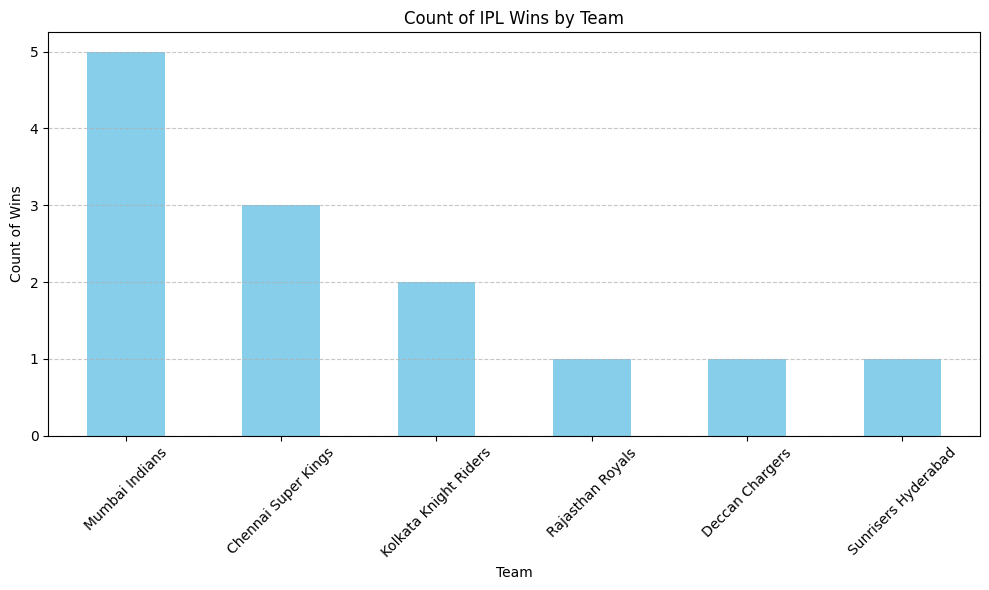

In [27]:
winners_counts = winners_of_IPL['team'].value_counts()
plt.figure(figsize=(10, 6))
winners_counts.plot(kind='bar', color='skyblue')
plt.title('Count of IPL Wins by Team')
plt.xlabel('Team')
plt.ylabel('Count of Wins')
plt.xticks(rotation=45)  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.tight_layout()  
plt.show()

In [28]:
matches_played_by_teams = pd.concat([match_data['team1'], match_data['team2']], axis=1)

teams = (matches_played_by_teams['team1'].value_counts() + matches_played_by_teams['team2'].value_counts()).reset_index()
teams.columns = ['Team Name', 'Total Matches played']

teams = teams.sort_values(by='Total Matches played', ascending=False).reset_index(drop=True)
teams.style.background_gradient(cmap="PuBu")


,Team Name,Total Matches played
0,Mumbai Indians,203
1,Royal Challengers Bangalore,195
2,Kolkata Knight Riders,192
3,Kings XI Punjab,190
4,Chennai Super Kings,178
5,Delhi Daredevils,161
6,Rajasthan Royals,161
7,Sunrisers Hyderabad,124
8,Deccan Chargers,75
9,Pune Warriors,46


### 12.Total number of wins

In [29]:
colors = ['turquoise'] * 15
fig = px.bar(x=teams['Team Name'], y=teams['Total Matches played'], labels=dict(x="Team Name", y="Count"))

fig.update_layout(title="Total number of matches played", title_font=dict(size=26), template='simple_white')

fig.update_traces(marker_line_color="black", marker_line_width=2.5, opacity=1, marker_color=colors)
fig.show()

In [30]:
wins = pd.DataFrame(match_data['winner'].value_counts()).reset_index()
wins.columns = ['Team Name', 'Wins']
wins.style.background_gradient(cmap='BuPu')

,Team Name,Wins
0,Mumbai Indians,120
1,Chennai Super Kings,106
2,Kolkata Knight Riders,99
3,Royal Challengers Bangalore,91
4,Kings XI Punjab,88
5,Rajasthan Royals,81
6,Delhi Daredevils,67
7,Sunrisers Hyderabad,66
8,Deccan Chargers,29
9,Delhi Capitals,19


### 13.Win percentage by teams


In [31]:
played = teams.merge(wins, on='Team Name', how='inner')
played['% Win'] = (played['Wins'] / played['Total Matches played']) * 100
played = played.sort_values(by='% Win', ascending=False).reset_index(drop=True)
played.style.background_gradient(cmap='RdPu', subset=['% Win'])

,Team Name,Total Matches played,Wins,% Win
0,Rising Pune Supergiant,16,10,62.500000
1,Chennai Super Kings,178,106,59.550562
2,Mumbai Indians,203,120,59.113300
3,Delhi Capitals,33,19,57.575758
4,Sunrisers Hyderabad,124,66,53.225806
5,Kolkata Knight Riders,192,99,51.562500
6,Rajasthan Royals,161,81,50.310559
7,Royal Challengers Bangalore,195,91,46.666667
8,Kings XI Punjab,190,88,46.315789
9,Gujarat Lions,30,13,43.333333


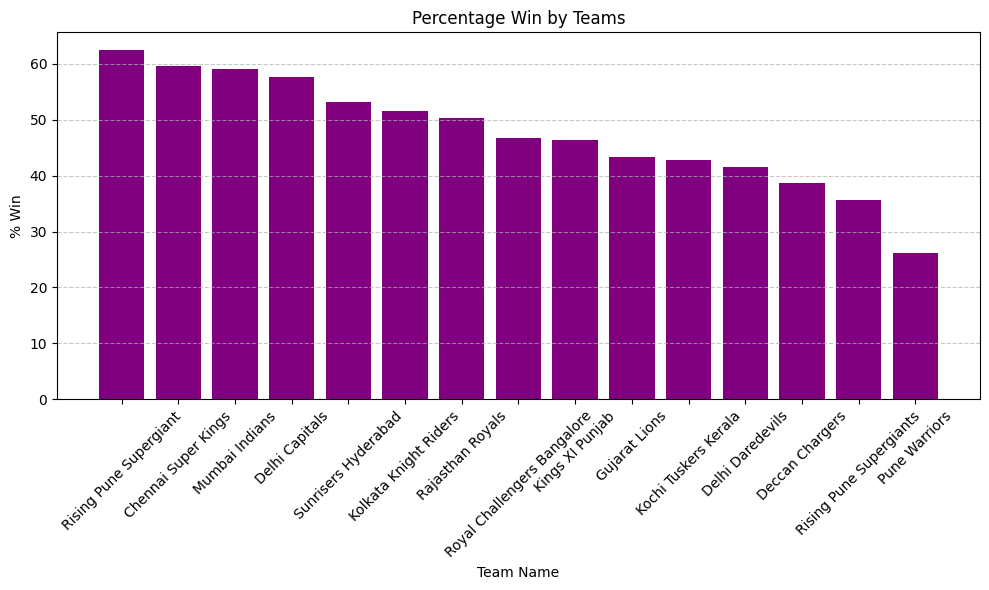

In [32]:
plt.figure(figsize=(10, 6))
plt.bar(played['Team Name'], played['% Win'], color='purple')
plt.title('Percentage Win by Teams')
plt.xlabel('Team Name')
plt.ylabel('% Win')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 14. Comparison between two teams

In [33]:
team_A_data = deliveries_data[deliveries_data['batting_team'] == 'Mumbai Indians']
team_B_data = deliveries_data[deliveries_data['batting_team'] == 'Chennai Super Kings']

In [34]:
total_runs_team_A = deliveries_data['total_runs'].sum()
total_runs_team_B = deliveries_data['total_runs'].sum()
average_runs_per_match_team_A = total_runs_team_A / len(team_A_data['id'].unique())
average_runs_per_match_team_B = total_runs_team_B / len(team_B_data['id'].unique())
run_rate_team_A = total_runs_team_A / len(team_A_data)
run_rate_team_B = total_runs_team_B / len(team_B_data)

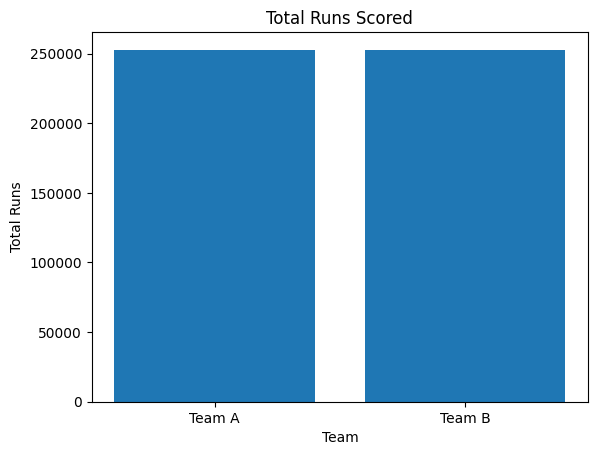

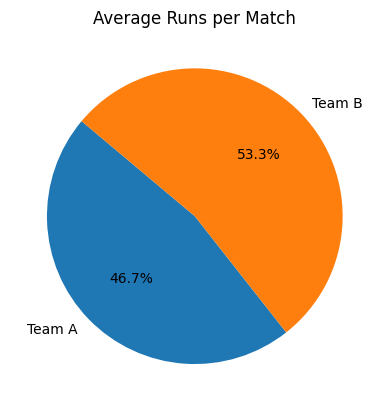

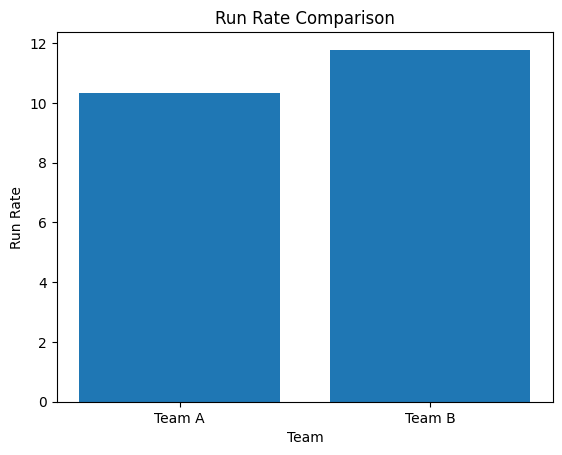

In [35]:
import matplotlib.pyplot as plt
plt.bar(['Team A', 'Team B'], [total_runs_team_A, total_runs_team_B])
plt.title('Total Runs Scored')
plt.xlabel('Team')
plt.ylabel('Total Runs')
plt.show()
labels = ['Team A', 'Team B']
sizes = [average_runs_per_match_team_A, average_runs_per_match_team_B]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Average Runs per Match')
plt.show()
plt.bar(['Team A', 'Team B'], [run_rate_team_A, run_rate_team_B])
plt.title('Run Rate Comparison')
plt.xlabel('Team')
plt.ylabel('Run Rate')
plt.show()

### 15.Particular batsman analysis.

In [37]:
deliveries_data = deliveries_data[deliveries_data['batsman'] == 'SC Ganguly']
total_runs = deliveries_data['batsman_runs'].sum()
matches_played = len(deliveries_data['id'].unique())
batting_average = total_runs / matches_played
balls_faced = len(deliveries_data)
strike_rate = (total_runs / balls_faced) * 100
fours = deliveries_data[deliveries_data['batsman_runs'] == 4].shape[0]
sixes = deliveries_data[deliveries_data['batsman_runs'] == 6].shape[0]

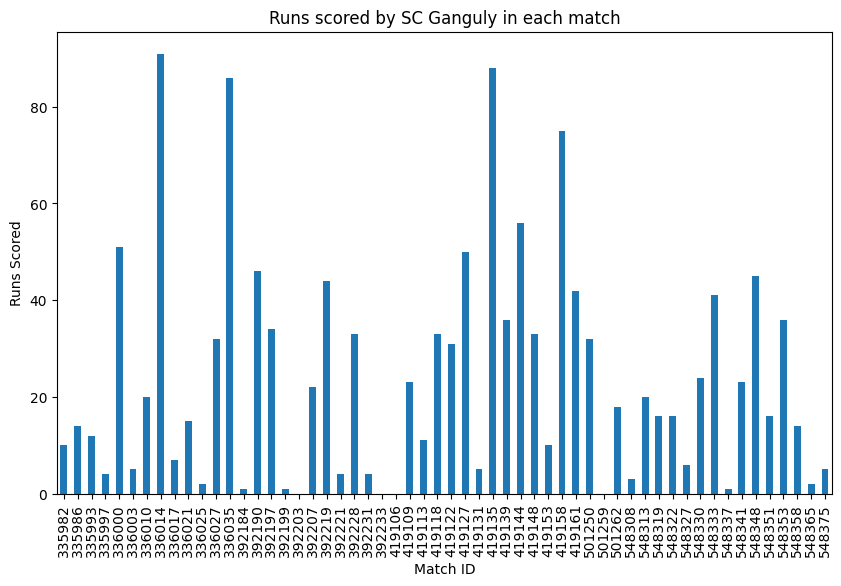

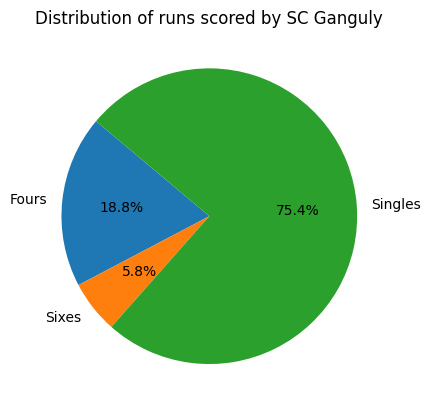

In [38]:
deliveries_data.groupby('id')['batsman_runs'].sum().plot(kind='bar', figsize=(10, 6))
plt.title('Runs scored by SC Ganguly in each match')
plt.xlabel('Match ID')
plt.ylabel('Runs Scored')
plt.show()
labels = ['Fours', 'Sixes', 'Singles']
sizes = [fours, sixes, total_runs - (4 * fours + 6 * sixes)]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of runs scored by SC Ganguly')
plt.show()

### 16.Innings wise comparison.

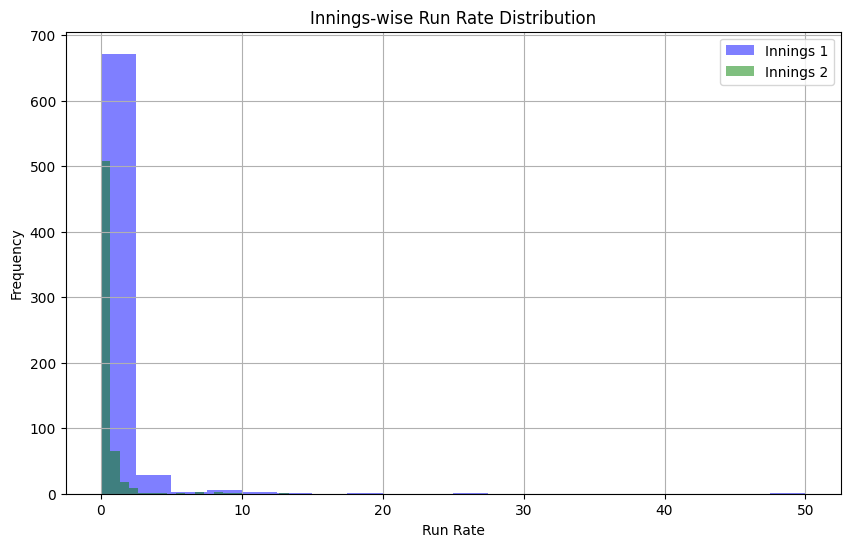

In [39]:
deliveries_data['run_rate'] =deliveries_data.groupby(['id', 'inning'])['total_runs'].cumsum() / (deliveries_data['over'] * 6 + deliveries_data['ball'])
innings_run_rate = deliveries_data.groupby('inning')['run_rate'].mean()
plt.figure(figsize=(10, 6))
plt.hist(deliveries_data[deliveries_data['inning'] == 1]['run_rate'], bins=20, alpha=0.5, label='Innings 1', color='blue')
plt.hist(deliveries_data[deliveries_data['inning'] == 2]['run_rate'], bins=20, alpha=0.5, label='Innings 2', color='green')
plt.xlabel('Run Rate')
plt.ylabel('Frequency')
plt.title('Innings-wise Run Rate Distribution')
plt.legend()
plt.grid(True)
plt.show()

### 17.Scored 200+ runs.

In [41]:
high_scores=deliveries_data.groupby(['id','inning','batting_team','bowling_team'])['total_runs'].sum().reset_index()
score_200=high_scores[high_scores['total_runs']>=200]
score_200.head(5)

,id,inning,batting_team,bowling_team,total_runs


In [42]:
x1 = score_200['batting_team'].value_counts()
x1 = pd.DataFrame(x1)
styled_df = x1.style.background_gradient(cmap='PuBu')
z = score_200['bowling_team'].value_counts()
z = pd.DataFrame(z)
z.style.background_gradient(cmap='PuBu')

,count
bowling_team,


### 18.Which is the biggest win teams of run margin?

In [43]:
z = score_200['bowling_team'].value_counts()
z_df = pd.DataFrame(z)
styled_z = z_df.style.background_gradient(cmap='PuBu')
styled_z

,count
bowling_team,


### 19.Which batsmen have played most number of balls?

In [44]:
total_balls_by_batsman = deliveries_data.groupby('batsman')['ball'].sum()
largest_total_balls = total_balls_by_batsman.max()
print("Batsman with the largest total balls:")
print(total_balls_by_batsman[total_balls_by_batsman == largest_total_balls])

Batsman with the largest total balls:
batsman
SC Ganguly    4837
Name: ball, dtype: int64


### 20.Who are leading run scores of all time?

In [45]:
total_runs = deliveries_data.groupby('batsman')['total_runs'].sum()
top=total_runs.sort_values(ascending=False)
top.head()

batsman
SC Ganguly    1464
Name: total_runs, dtype: int64

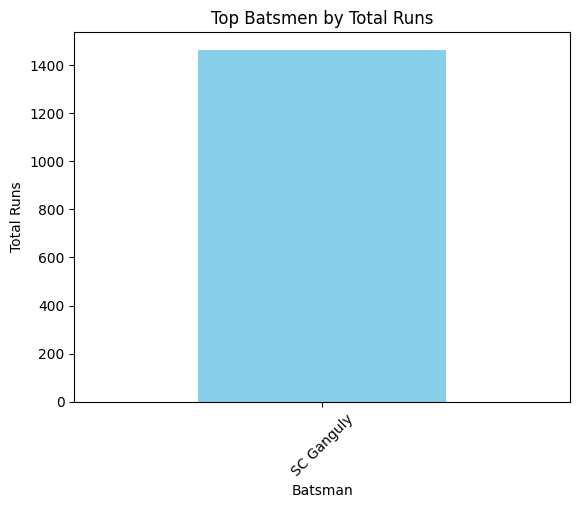

In [46]:
total_runs = deliveries_data.groupby('batsman')['total_runs'].sum()
top_batsmen = total_runs.sort_values(ascending=False).head()
top_batsmen.plot(kind='bar', color='skyblue')
plt.title('Top Batsmen by Total Runs')
plt.xlabel('Batsman')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.show()

### 21.Who has hit most number of 4's?

In [47]:
fours_data = deliveries_data[deliveries_data['total_runs'] == 4]
fours_by_batsman = fours_data.groupby('batsman').size()
top_fours_batsmen = fours_by_batsman.sort_values(ascending=False)
print("Top batsmen by the number of 4's:")
print(top_fours_batsmen.head(1))

Top batsmen by the number of 4's:
batsman
SC Ganguly    138
dtype: int64


### 22.Who has hit most number of 6's?

In [48]:
s_data = deliveries_data[deliveries_data['total_runs'] == 6]
s_by_batsman = s_data.groupby('batsman').size()
top_s_batsmen = s_by_batsman.sort_values(ascending=False)
print("Top batsmen by the number of 6's:")
print(top_s_batsmen.head(1))

Top batsmen by the number of 6's:
batsman
SC Ganguly    41
dtype: int64


### 23..Who has won the most MOM awards?

In [49]:
mom= match_data['player_of_match'].value_counts().idxmax()
print( mom,'has won most MOM awards.')

AB de Villiers has won most MOM awards.


### 24.Which team has scored the most runs in the first 6 overs?


In [50]:
first_six_overs = deliveries_data[deliveries_data['over'] <= 6]
first_six_overs_with_teams = pd.merge(first_six_overs, match_data[['id', 'team1', 'team2']], left_on='id', right_on='id')
runs_by_team = first_six_overs_with_teams.groupby('batting_team')['total_runs'].sum()
team_with_most_runs = runs_by_team.idxmax()
print("Team with the most runs in the first 6 overs:", team_with_most_runs)

Team with the most runs in the first 6 overs: Kolkata Knight Riders


### 25.Which team has scored the most runs in the last 4 overs?

In [51]:
last_4_overs_data = deliveries_data[(deliveries_data['over'] >= 17) & (deliveries_data['over'] <= 20)]
runs_scored_last_4_overs = last_4_overs_data.groupby('batting_team')['total_runs'].sum()
team_with_most_runs_last_4_overs = runs_scored_last_4_overs.idxmax()
print("Team with the most runs scored in the last 4 overs:", team_with_most_runs_last_4_overs)

Team with the most runs scored in the last 4 overs: Kolkata Knight Riders


### 26.Which team has the best scoring run-rate in the first 6 overs?

In [52]:
first_6_overs_data = deliveries_data[deliveries_data['over'] <= 6]
runs_scored_first_6_overs = first_6_overs_data.groupby('batting_team')['total_runs'].sum()
balls_faced_first_6_overs = first_6_overs_data.groupby('batting_team').size()
run_rate_first_6_overs = (runs_scored_first_6_overs / balls_faced_first_6_overs) * 6
team_with_best_run_rate = run_rate_first_6_overs.idxmax()
print("Team with the best scoring run-rate in the first 6 overs:", team_with_best_run_rate)

Team with the best scoring run-rate in the first 6 overs: Kolkata Knight Riders


### 27.Which team has the best scoring run-rate in the first 4 overs?

In [53]:
first_4_overs_data = deliveries_data[deliveries_data['over'] <= 4]
runs_scored_first_4_overs = first_4_overs_data.groupby('batting_team')['total_runs'].sum()
balls_faced_first_4_overs = first_4_overs_data.groupby('batting_team').size()
run_rate_first_4_overs = (runs_scored_first_4_overs / balls_faced_first_4_overs) * 6  
team_with_best_run_rate_first_4_overs = run_rate_first_4_overs.idxmax()
print("Team with the best scoring run-rate in the first 4 overs:", team_with_best_run_rate_first_4_overs)

Team with the best scoring run-rate in the first 4 overs: Pune Warriors
